In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from urllib.request import urlopen
import json
import os
from json import loads
import plotly.express as px

## Helper functions to search for school

In [6]:
school_df = pd.read_csv("schoolname_UNITID.csv")

def search_school(school_name):
    # Case-insensitive search for school name
    result = school_df[school_df["inst_name"].str.contains(school_name, case=False, na=False)]
    if result.empty:
        print(f"No matches found for '{school_name}'.")
    return result

def get_school_name(unitid):
    # Fetch school directory data
    url = f"https://educationdata.urban.org/api/v1/college-university/ipeds/directory/2020/?unitid={unitid}"
    response = urlopen(url)
    data = loads(response.read())
    
    results = data.get("results", [])
    if results:
        school_name = results[0].get("inst_name", "Unknown")
        return school_name
    else:
        return f"No school found for unitid {unitid}"

def search_school_by_state(state_abbr):
    """Search for schools in a given state (by abbreviation) and return a DataFrame with unitid and school name.
    """
    url = "https://educationdata.urban.org/api/v1/college-university/ipeds/directory/2020/"
    
    try:
        response = urlopen(url)
        data = loads(response.read())
        results = data.get("results", [])
        
        if not results:
            print(f"No schools found.")
            return pd.DataFrame()
        
        # Filter results manually based on state_abbr
        filtered_results = [
            {"unitid": result.get("unitid"), "school_name": result.get("inst_name", "Unknown")}
            for result in results if result.get("state_abbr") == state_abbr.upper()
        ]
        
        if not filtered_results:
            print(f"No schools found in {state_abbr}.")
            return pd.DataFrame()
        
        return pd.DataFrame(filtered_results)
    
    except Exception as e:
        print(f"Error fetching data: {e}")
        return pd.DataFrame()
        

In [8]:
search_school_by_state("nj")

,unitid,school_name
0,183488,Eastwick College-Hackensack
1,183600,Assumption College for Sisters
2,183655,Atlantic Cape Community College
3,183725,Fortis Institute-Wayne
4,183743,Bergen Community College
...,...,...
160,493628,Pro Beauty Academy
161,493707,Yeshiva Gedolah of Woodlake Village
162,493716,Yeshiva Gedola Tiferes Yaakov Yitzchok
163,495314,Hackensack Meridian School of Medicine


Get a UNITIDs of New Jersey schools

In [6]:
NJ_schools = search_school_by_state("nj")

if not NJ_schools.empty:
    # Extract the list of unitid values
    NJ_unitid_list = NJ_schools["unitid"].tolist()
    print("List of UNITIDs for schools in New Jersey:", NJ_unitid_list)

    # Fetch and print school names for each unitid
    for unitid in NJ_unitid_list:
        school_name = get_school_name(unitid)
        print(f"UNITID: {unitid}, School Name: {school_name}")
else:
    print("No schools found in New Jersey.")

List of UNITIDs for schools in New Jersey: [183488, 183600, 183655, 183725, 183743, 183789, 183804, 183822, 183859, 183877, 183910, 183938, 183974, 183983, 184047, 184056, 184092, 184180, 184205, 184278, 184348, 184427, 184481, 184506, 184603, 184612, 184694, 184746, 184773, 184782, 184791, 184816, 184870, 184959, 184968, 184995, 185129, 185174, 185262, 185332, 185396, 185466, 185509, 185536, 185572, 185590, 185679, 185721, 185758, 185767, 185828, 185873, 185970, 186016, 186034, 186052, 186122, 186131, 186186, 186201, 186283, 186371, 186380, 186399, 186405, 186423, 186432, 186469, 186584, 186593, 186618, 186645, 186867, 186876, 186900, 187000, 187046, 187134, 187198, 187444, 194718, 245625, 247603, 249140, 363077, 365763, 368230, 374574, 374592, 383279, 384421, 407391, 407407, 407425, 414063, 417831, 420130, 420343, 421878, 430218, 430403, 431716, 436003, 437723, 440794, 441548, 442073, 443216, 443225, 445300, 446224, 446303, 448354, 448983, 449658, 451370, 451398, 453215, 455187, 4551

## Plot from raw data

In [ ]:
# Read multiple years of graduation data and add survey year column
df_2023 = pd.read_csv("../data/grad/gr2023.csv")
df_2023['Survey_Year'] = 2023

df_2022 = pd.read_csv("../data/grad/gr2022.csv")
df_2022['Survey_Year'] = 2022

df_2021 = pd.read_csv("../data/grad/gr2021.csv") 
df_2021['Survey_Year'] = 2021

df_2020 = pd.read_csv("../data/grad/gr2020.csv")
df_2020['Survey_Year'] = 2020

# Combine all years into one dataframe
df = pd.concat([df_2023, df_2022, df_2021, df_2020], ignore_index=True)
print(df.head())
# Save the merged dataframe to CSV
# df.to_csv("../data/grad/merged_raw_grdata.csv", index=False)


   UNITID  GRTYPE  CHRTSTAT  SECTION  COHORT LINE XGRTOTLT  GRTOTLT XGRTOTLM  \
0  100654       1        10        1       1  999        R     1286        R   
1  100654       2        12        1       1  999        R     1284        R   
2  100654       3        13        1       1  999        R      369        R   
3  100654       4        20        1       1  999        R      393        R   
4  100654       6        10        2       2  10         R     1286        R   

   GRTOTLM  ... GRUNKNM  XGRUNKNW GRUNKNW  XGRNRALT GRNRALT  XGRNRALM GRNRALM  \
0    514.0  ...    22.0         R    46.0         R     9.0         R     3.0   
1    513.0  ...    22.0         R    46.0         R     9.0         R     3.0   
2    112.0  ...     6.0         R    23.0         R     5.0         R     2.0   
3    130.0  ...     4.0         R    16.0         R     0.0         R     0.0   
4    514.0  ...    22.0         R    46.0         R     9.0         R     3.0   

   XGRNRALW GRNRALW   Survey_Yea

In [61]:
column_mapping = {
    "UNITID": "UNITID",
    "Survey_Year": "Survey_Year",
    "GRTYPE": "Graduation_Status",
    "CHRTSTAT": "Graduation_rate_status_in_cohort",
    "COHORT": "Cohort",
    "GRTOTLT": "Total",
    "GRTOTLM": "Total_men",
    "GRTOTLW": "Total_women",
    "GRAIANT": "American_Indian_total",
    "GRAIANM": "American_Indian_men",
    "GRAIANW": "American_Indian_women",
    "GRASIAT": "Asian_total",
    "GRASIAM": "Asian_men",
    "GRASIAW": "Asian_women",
    "GRBKAAT": "Black_total",
    "GRBKAAM": "Black_men",
    "GRBKAAW": "Black_women",
    "GRHISPT": "Hispanic_total",
    "GRHISPM": "Hispanic_men",
    "GRHISPW": "Hispanic_women",
    "GRNHPIT": "Native_Hawaiian_total",
    "GRNHPIM": "Native_Hawaiian_men",
    "GRNHPIW": "Native_Hawaiian_women",
    "GRWHITT": "White_total",
    "GRWHITM": "White_men",
    "GRWHITW": "White_women",
    "GR2MORT": "Two_or_more_races_total",
    "GR2MORM": "Two_or_more_races_men",
    "GR2MORW": "Two_or_more_races_women",
    "GRUNKNT": "Race_unknown_total",
    "GRUNKNM": "Race_unknown_men",
    "GRUNKNW": "Race_unknown_women",
    "GRNRALT": "Nonresident_alien_total",
    "GRNRALM": "Nonresident_alien_men",
    "GRNRALW": "Nonresident_alien_women",
}

grtype_mapping = {
    1: "4-year institutions revised cohort",
    2: "4-year institutions, Adjusted cohort (revised cohort minus exclusions)",
    3: "4-year institutions, Completers within 150% of normal time",
    4: "4-year institutions, Transfer-out students",
    6: "Bachelor's or equiv subcohort (4-yr institution)",
    7: "Bachelor's or equiv subcohort (4-yr institution) exclusions",
    8: "Bachelor's or equiv subcohort (4-yr institution) adjusted cohort (revised cohort minus exclusions)",
    9: "Bachelor's or equiv subcohort (4-yr institution) Completers within 150% of normal time total",
    10: "Bachelor's or equiv subcohort (4-yr institution) Completers of programs of < 2 yrs (150% of normal time)",
    11: "Bachelor's or equiv subcohort (4-yr institution) Completers of programs of 2 but <4 yrs (150% of normal time)",
    12: "Bachelor's or equiv subcohort (4-yr institution) Completers of bachelor's or equiv degrees total (150% of normal time)",
    13: "Bachelor's or equiv subcohort (4-yr institution) Completers of bachelor's or equiv degrees in 4 years or less",
    14: "Bachelor's or equiv subcohort (4-yr institution) Completers of bachelor's or equiv degrees in 5 years",
    15: "Bachelor's or equiv subcohort (4-yr institution) Completers of bachelor's or equiv degrees in 6 years",
    16: "Bachelor's or equiv subcohort (4-yr institution) Transfer-out students",
    18: "Other degree/certif-seeking subcohort (4-yr institution)",
    19: "Other degree/certificate-seeking subcohort(4-yr institution) exclusions",
    20: "Other degree/certif-seeking subcohort (4-yr institution) Adjusted cohort (revised cohort minus exclusions)",
    21: "Other degree/certif-seeking subcohort (4-yr institution) Completers within 150% of normal time total",
    22: "Other degree/certif-seeking subcohort (4-yr institution) Completers of programs < 2 yrs (150% of normal time)",
    23: "Other degree/certif-seeking subcohort (4-yr institution) Completers of programs of 2 but < 4 yrs (150% of normal time)",
    24: "Other degree/certif-seeking subcohort (4-yr institution) Completers of bachelor's or equiv degrees (150% of normal time)",
    25: "Other degree/certif-seeking subcohort (4-yr institution) Transfer-out students",
    27: "Degree/certif-seeking students ( 2-yr institution) revised cohort",
    28: "Degree/certificate-seeking subcohort(2-yr institution) exclusions",
    29: "Degree/certif-seeking students ( 2-yr institution) Adjusted cohort (revised cohort minus exclusions)",
    30: "Degree/certif-seeking students ( 2-yr institution) Completers within 150% of normal time total",
    31: "Degree/certif-seeking students ( 2-yr institution) Completers of programs of < 2 yrs (150% of normal time)",
    32: "Degree/certificate-seeking students ( 2-yr institution) Completers of programs of 2 but < 4 yrs (150% of normal time)",
    33: "Degree/certif-seeking students ( 2-yr institution) Transfer-out students",
    35: "Degree/certif-seeking students ( 2-yr institution) Completers within 100% of normal time total",
    36: "Degree/certif-seeking students ( 2-yr institution) Completers of programs of < 2 yrs (100% of normal time)",
    37: "Degree/certificate-seeking students ( 2-yr institution) Completers of programs of 2 but < 4 yrs (100% of normal time)",
    40: "Total exclusions 4-year schools",
    41: "4-year institutions, noncompleters still enrolled",
    42: "4-year institutions, No longer enrolled",
    43: "Bachelor's or equiv subcohort (4-yr institution) noncompleters still enrolled",
    44: "Bachelor's or equiv subcohort (4-yr institution), No longer enrolled",
    45: "Other degree/certif-seeking subcohort (4-yr institution) noncompleters still enrolled",
    46: "Other degree/certif-seeking subcohort (4-yr institution) No longer enrolled",
    47: "Degree/certif-seeking students ( 2-yr institution) noncompleters still enrolled",
    48: "Degree/certif-seeking students ( 2-yr institution) No longer enrolled",
}

In [62]:
# WORKING WITH PROCESSED DATA
# Keep only desired columns
cols = ["UNITID", "Survey_Year", "GRTYPE", "GRTOTLT"]
grdf = df[cols]

# Create a copy of raw ipeds to perform rename and value mapping
processed_df = grdf.copy()

# --- Rename columns
processed_df.rename(columns=column_mapping, inplace=True)

# --- Map the Graduation_Status values according to grtype_mapping in processed_df
processed_df['Graduation_Status'] = processed_df['Graduation_Status'].map(grtype_mapping)

print("Data shape:", processed_df.shape)
print("NJIT DataFrame 2023")
processed_df[processed_df['UNITID'] == 185828]

Data shape: (199156, 4)
NJIT DataFrame 2023


,UNITID,Survey_Year,Graduation_Status,Total
21642,185828,2023,4-year institutions revised cohort,1071
21643,185828,2023,"4-year institutions, Adjusted cohort (revised ...",1060
21644,185828,2023,"4-year institutions, Completers within 150% of...",775
21645,185828,2023,"4-year institutions, Transfer-out students",93
21646,185828,2023,Bachelor's or equiv subcohort (4-yr institution),1071
...,...,...,...,...
170255,185828,2020,Total exclusions 4-year schools,6
170256,185828,2020,"4-year institutions, noncompleters still enrolled",19
170257,185828,2020,"4-year institutions, No longer enrolled",45
170258,185828,2020,Bachelor's or equiv subcohort (4-yr institutio...,19


In [63]:
# WORKING DIRECTLY ON RAW DATA
# Build condition: grtype == 8 OR grtype == 13
condition = (df["GRTYPE"] == 8) | (df["GRTYPE"] == 13)

# Keep only desired columns
cols = ["UNITID", "Survey_Year", "GRTYPE", "GRTOTLT"]
grdf = df[cols][condition]

# Show NJIT rows
grdf[grdf['UNITID'] == 185828]

,UNITID,Survey_Year,GRTYPE,GRTOTLT
21648,185828,2023,8,1060
21651,185828,2023,13,524
71619,185828,2022,8,1031
71622,185828,2022,13,499
120618,185828,2021,8,977
120621,185828,2021,13,376
170248,185828,2020,8,930
170251,185828,2020,13,382


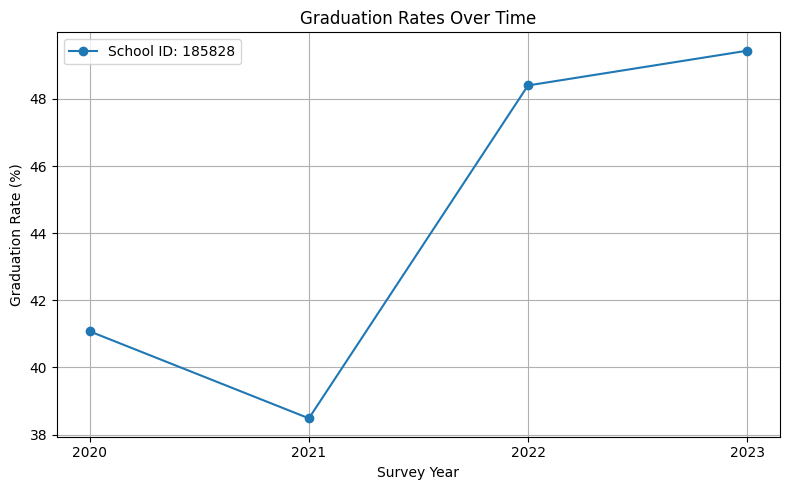

In [ ]:
def plot_graduation_rates(unitid):
    # Calculate graduation rates using GRTYPE 8 (denominator) and 13 (numerator)
    grad_rates = []
    for year in grdf['Survey_Year'].unique():
        unit_year_data = grdf[(grdf['UNITID'] == unitid) & (grdf['Survey_Year'] == year)]
        
        # Get denominator (GRTYPE 8) and numerator (GRTYPE 13) values
        denominator = unit_year_data[unit_year_data['GRTYPE'] == 8]['GRTOTLT'].values
        numerator = unit_year_data[unit_year_data['GRTYPE'] == 13]['GRTOTLT'].values
        
        # Only calculate rate if we have both values
        if len(denominator) > 0 and len(numerator) > 0:
            rate = (numerator[0] / denominator[0]) * 100
            grad_rates.append({
                'UNITID': unitid,
                'Survey_Year': year,
                'Graduation_Rate': rate
            })

    # Convert to DataFrame
    grad_rates_df = pd.DataFrame(grad_rates)

    # Create the plot
    plt.figure(figsize=(8, 5))
    plt.xticks(grad_rates_df['Survey_Year'])
    plt.plot(grad_rates_df['Survey_Year'], grad_rates_df['Graduation_Rate'],
             marker='o', label=f'School ID: {unitid}', 
             linestyle='-', markersize=8)
    # Add data point labels
    for x, y in zip(grad_rates_df['Survey_Year'], grad_rates_df['Graduation_Rate']):
        plt.annotate(f'{y:.1f}%', 
                    (x, y),
                    textcoords="offset points",
                    xytext=(0,10),
                    ha='center')

    plt.title('Graduation Rates by Cohort')
    # Convert x-axis to cohort years
    cohort_years = grad_rates_df['Survey_Year'] - 6
    plt.xticks(grad_rates_df['Survey_Year'], cohort_years)
    plt.xlabel('Cohort Year')
    plt.ylabel('Graduation Rate (%)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

plot_graduation_rates(185828)

## Plot

In [4]:
def process_graduation_data(unitid, folder_path="grad"):
    """
    Process graduation rate data for a given unitid across files like gr2022.csv, gr20233.csv.
    """
    variable_mapping = {
        "GRTYPE": "Cohort_type",
        "CHRTSTAT": "Graduation_rate_status_in_cohort",
        "COHORT": "Cohort",
        "GRTOTLT": "Total",
        "GRTOTLM": "Total_men",
        "GRTOTLW": "Total_women",
        "GRAIANT": "American_Indian_total",
        "GRAIANM": "American_Indian_men",
        "GRAIANW": "American_Indian_women",
        "GRASIAT": "Asian_total",
        "GRASIAM": "Asian_men",
        "GRASIAW": "Asian_women",
        "GRBKAAT": "Black_total",
        "GRBKAAM": "Black_men",
        "GRBKAAW": "Black_women",
        "GRHISPT": "Hispanic_total",
        "GRHISPM": "Hispanic_men",
        "GRHISPW": "Hispanic_women",
        "GRNHPIT": "Native_Hawaiian_total",
        "GRNHPIM": "Native_Hawaiian_men",
        "GRNHPIW": "Native_Hawaiian_women",
        "GRWHITT": "White_total",
        "GRWHITM": "White_men",
        "GRWHITW": "White_women",
        "GR2MORT": "Two_or_more_races_total",
        "GR2MORM": "Two_or_more_races_men",
        "GR2MORW": "Two_or_more_races_women",
        "GRUNKNT": "Race_unknown_total",
        "GRUNKNM": "Race_unknown_men",
        "GRUNKNW": "Race_unknown_women",
        "GRNRALT": "Nonresident_alien_total",
        "GRNRALM": "Nonresident_alien_men",
        "GRNRALW": "Nonresident_alien_women",
    }

    dataframes = []

    for filename in os.listdir(folder_path):
        if not filename.startswith("gr") or not filename.endswith(".csv") or filename.endswith("_dict.csv"):
            continue

        # Extract year from filename
        year_digits = ''.join(filter(str.isdigit, filename))
        year = int(year_digits[:4])  # '20233' -> 2023

        file_path = os.path.join(folder_path, filename)
        df = pd.read_csv(file_path)

        df = df[df["UNITID"] == unitid]
        selected_cols = [col for col in df.columns if col in variable_mapping]

        if not selected_cols:
            continue

        df = df[selected_cols].copy()
        df["year"] = year
        df["unitid"] = unitid
        df["university_name"] = get_school_name(unitid)
        df.rename(columns=variable_mapping, inplace=True)

        dataframes.append(df)

    if not dataframes:
        print(f"No graduation data found for unitid {unitid}.")
        return pd.DataFrame()

    final_df = pd.concat(dataframes, ignore_index=True)
    col_order = ["unitid", "university_name", "year"] + [col for col in final_df.columns if col not in ["unitid", "university_name", "year"]]
    return final_df[col_order]


In [7]:
all_data = pd.DataFrame()
for unitid in NJ_unitid_list:
    unitid_data = process_graduation_data(unitid)
    if not unitid_data.empty:
        all_data = pd.concat([all_data, unitid_data], ignore_index=True)

output_path = "grad/NJ_graduation_data.csv"
all_data.to_csv(output_path, index=False)

print(f"All data saved to: {output_path}")

All data saved to: grad/NJ_graduation_data.csv


In [30]:
def plot_graduation_funnel(df, selected_unitid=None, selected_year=None):
    # Filter if needed
    if selected_unitid:
        df = df[df["UNITID"] == selected_unitid]
    if selected_year:
        df = df[df["year"] == selected_year]

    # Define CHRTSTAT codes and their funnel stage labels
    funnel_stages = {
        12: "Adjusted Cohort",       # Enrolled students (after exclusions)
        22: "Completed in 100%",     # Graduated within 100% of normal time
        13: "Completed in 150%",     # Graduated within 150% of normal time
        20: "Transferred Out"        # Transfer-out students
    }

    # Aggregate totals for each stage
    stage_names = []
    student_counts = []

    for code, label in funnel_stages.items():
        count = df[df["Graduation_rate_status_in_cohort"] == code]["Total"].sum()
        stage_names.append(label)
        student_counts.append(count)

    # Plotting
    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.barh(stage_names[::-1], student_counts[::-1], color="#2ca02c")

    for bar in bars:
        width = bar.get_width()
        ax.text(width + max(student_counts) * 0.01, bar.get_y() + bar.get_height()/2,
                f'{int(width):,}', va='center', fontsize=10)

    ax.set_title("Graduation Funnel", fontsize=14, fontweight='bold')
    ax.set_xlabel("Number of Students")
    ax.set_ylabel("Cohort Status")
    ax.invert_yaxis()
    ax.grid(axis="x", linestyle="--", alpha=0.6)

    plt.tight_layout()
    plt.show()


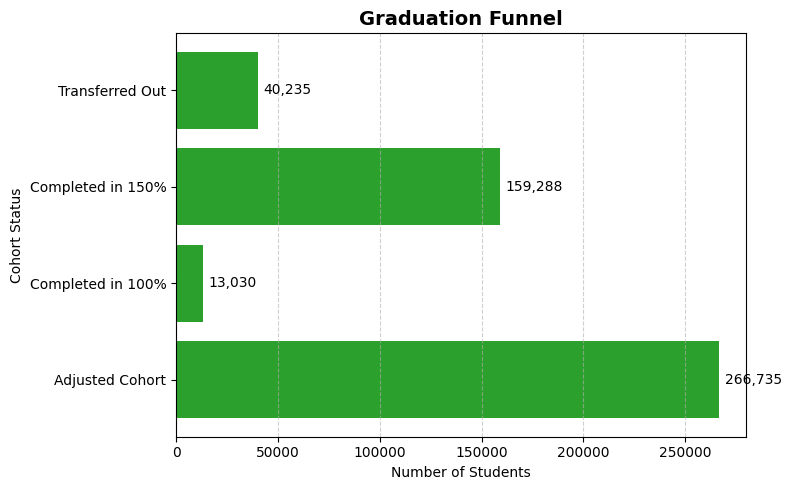

In [ ]:

df_grads = pd.read_csv("grad/NJ_graduation_data.csv")
plot_graduation_funnel(df_grads, "2020")


# Map

In [1]:
import pandas as pd

In [2]:
# Paths
graduation_path = "/Users/uyennguyen/Projects/DA/Data-Viz-IPEDS/data/dbt-processed/graduation.csv"
schoolinfo_path = "/Users/uyennguyen/Projects/DA/Data-Viz-IPEDS/data/schoolinfo.csv"
out_path = "/Users/uyennguyen/Projects/DA/Data-Viz-IPEDS/data/dbt-processed/graduation_mapped.csv"

# Load
grad = pd.read_csv(graduation_path)
school = pd.read_csv(schoolinfo_path)

# Normalize UNITID types for a clean join
grad["INSTITUTION_ID"] = pd.to_numeric(grad["INSTITUTION_ID"], errors="coerce").astype("Int64")
school["UNITID"] = pd.to_numeric(school["UNITID"], errors="coerce").astype("Int64")

/var/folders/63/lvrmvc5j7pn6bxjxzcd1txt00000gn/T/ipykernel_8459/3227626409.py:7: DtypeWarning: Columns (2,3,4) have mixed types. Specify dtype option on import or set low_memory=False.
  grad = pd.read_csv(graduation_path)


In [3]:
# Keep only needed columns from schoolinfo
school_slim = school[["UNITID", "INSTNM", "STABBR", "STATE", "CITY", "ZIP"]].drop_duplicates(subset=["UNITID"])

# Merge (INSTITUTION_ID in grad ↔ UNITID in school)
merged = grad.merge(
    school_slim,
    left_on="INSTITUTION_ID",
    right_on="UNITID",
    how="left",
    suffixes=("", "_school")
)

# Prefer schoolinfo values for CITY/ZIP; then drop the duplicate columns
for col in ["CITY", "ZIP"]:
    alt = f"{col}_school"
    if alt in merged.columns:
        merged[col] = merged[alt].where(merged[alt].notna(), merged.get(col))
        merged = merged.drop(columns=[alt])

# Map to requested column names
merged["INSTITUTION_NAME"] = merged["INSTNM"]
merged["STATE_ABBR"] = merged["STABBR"]

desired = ["INSTITUTION_ID", "INSTITUTION_NAME", "ZIP", "CITY", "STATE_ABBR", "STATE", "SURVEY_YEAR"]
rest = [c for c in merged.columns if c not in desired]

merged = merged[desired + rest]

# Clean helper columns
merged = merged.drop(columns=["UNITID", "INSTNM", "STABBR"])
print(merged.shape)

(199156, 42)


In [4]:
# Treat NaN or whitespace-only as empty
mask_empty_name = merged["INSTITUTION_NAME"].isna() | (merged["INSTITUTION_NAME"].astype(str).str.strip() == "")
print(mask_empty_name.sum())

2166


In [5]:
merged.head()

,INSTITUTION_ID,INSTITUTION_NAME,ZIP,CITY,STATE_ABBR,STATE,SURVEY_YEAR,GRAD_TYPE,GRAD_STATUS,SECTION,...,GR_WHITE_FEMALE,GR_TWO_OR_MORE_ALL,GR_TWO_OR_MORE_MALE,GR_TWO_OR_MORE_FEMALE,GR_UNKNOWN_ALL,GR_UNKNOWN_MALE,GR_UNKNOWN_FEMALE,GR_NONRESIDENT_ALL,GR_NONRESIDENT_MALE,GR_NONRESIDENT_FEMALE
0,100654,Alabama A & M University,35762,Normal,AL,Alabama,2020,Total exclusions 4-year schools,Exclusions,Bachelor's/ equiv + other degree/certificate-...,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,100654,Alabama A & M University,35762,Normal,AL,Alabama,2020,Bachelor's or equiv subcohort (4-yr institutio...,Transfer-out students,Bachelor's or equiv 2017 subcohort (4-yr insti...,...,5.0,5.0,1.0,4.0,3.0,2.0,1.0,0.0,0.0,0.0
2,100654,Alabama A & M University,35762,Normal,AL,Alabama,2020,Bachelor's or equiv subcohort (4-yr institutio...,"Noncompleters, no longer enrolled",Bachelor's or equiv 2017 subcohort (4-yr insti...,...,2.0,2.0,0.0,2.0,3.0,3.0,0.0,2.0,2.0,0.0
3,100654,Alabama A & M University,35762,Normal,AL,Alabama,2020,Bachelor's or equiv subcohort (4-yr institutio...,Adjusted cohort (revised cohort minus exclusions),Bachelor's or equiv 2017 subcohort (4-yr insti...,...,7.0,11.0,2.0,9.0,8.0,5.0,3.0,4.0,2.0,2.0
4,100654,Alabama A & M University,35762,Normal,AL,Alabama,2020,Bachelor's or equiv subcohort (4-yr institutio...,"Noncompleters, still enrolled",Bachelor's or equiv 2017 subcohort (4-yr insti...,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


In [6]:
# Drop rows with empty INSTITUTION_NAME
merged = merged[~mask_empty_name]

In [7]:
print(merged.shape)

(196990, 42)


In [8]:
# Save
merged.to_csv(out_path, index=False)
print(f"Saved: {out_path}")

Saved: /Users/uyennguyen/Projects/DA/Data-Viz-IPEDS/data/dbt-processed/graduation_mapped.csv


In [9]:
import pandas as pd

In [14]:
# Paths
enroll_path = "/Users/uyennguyen/Projects/DA/Data-Viz-IPEDS/data/processed/enrollment.csv"
schoolinfo_path = "/Users/uyennguyen/Projects/DA/Data-Viz-IPEDS/data/schoolinfo.csv"
out_path = "/Users/uyennguyen/Projects/DA/Data-Viz-IPEDS/data/processed/enrollment_mapped.csv"

# Load
enroll = pd.read_csv(enroll_path)
school = pd.read_csv(schoolinfo_path)

# Align join keys
enroll["INSTITUTION_ID"] = pd.to_numeric(enroll["INSTITUTION_ID"], errors="coerce").astype("Int64")
school["UNITID"] = pd.to_numeric(school["UNITID"], errors="coerce").astype("Int64")

/var/folders/63/lvrmvc5j7pn6bxjxzcd1txt00000gn/T/ipykernel_8459/3014783518.py:7: DtypeWarning: Columns (2,3,4) have mixed types. Specify dtype option on import or set low_memory=False.
  enroll = pd.read_csv(enroll_path)


In [ ]:
import pandas as pd

# Paths
enroll_path = "/Users/uyennguyen/Projects/DA/Data-Viz-IPEDS/dbt-preprocessing/processed/enrollment.csv"
schoolinfo_path = "/Users/uyennguyen/Projects/DA/Data-Viz-IPEDS/data/schoolinfo.csv"
out_path = "/Users/uyennguyen/Projects/DA/Data-Viz-IPEDS/dbt-preprocessing/processed/enrollment_mapped.csv"

# Load
enroll = pd.read_csv(enroll_path)
school = pd.read_csv(schoolinfo_path)

# Align join keys
enroll["INSTITUTION_ID"] = pd.to_numeric(enroll["INSTITUTION_ID"], errors="coerce").astype("Int64")
school["UNITID"] = pd.to_numeric(school["UNITID"], errors="coerce").astype("Int64")

# Helper: resolve columns by flexible candidates
school_cols_lower = {c.lower(): c for c in school.columns}
def pick(*cands):
    for c in cands:
        if c.lower() in school_cols_lower:
            return school_cols_lower[c.lower()]
    return None

col_unitid = "UNITID"  # already normalized
col_instnm = pick("INSTNM", "INSTITUTION_NAME", "NAME", "SCHOOL_NAME")
col_stabbr = pick("STABBR", "STATE_ABBR", "ABBR")
col_state  = pick("STATE", "state")
col_city   = pick("CITY", "City", "city", "TOWN")
col_zip    = pick("ZIP", "ZIPCODE", "ZIP_CODE", "POSTAL", "POSTAL_CODE")

missing = [name for name, col in {
    "UNITID": col_unitid,
    "INSTNM": col_instnm,
    "STABBR": col_stabbr,
    "STATE": col_state,
    "CITY": col_city,
    "ZIP": col_zip
}.items() if col is None]

if missing:
    raise KeyError(f"Missing expected column(s) in schoolinfo.csv: {', '.join(missing)}. "
                   f"Available: {list(school.columns)}")

# Build slim school df and standardize names
school_slim = school[[col_unitid, col_instnm, col_stabbr, col_state, col_city, col_zip]].drop_duplicates(subset=[col_unitid])
school_slim = school_slim.rename(columns={
    col_unitid: "UNITID",
    col_instnm: "INSTNM",
    col_stabbr: "STABBR",
    col_state:  "STATE",
    col_city:   "CITY",
    col_zip:    "ZIP"
})

# Merge (INSTITUTION_ID in enrollment ↔ UNITID in schoolinfo)
merged = enroll.merge(school_slim, left_on="INSTITUTION_ID", right_on="UNITID", how="left")

# Create requested mapped columns
merged["INSTITUTION_NAME"] = merged["INSTNM"]
merged["STATE_ABBR"] = merged["STABBR"]

# Reorder (only include if present)
desired = [c for c in ["INSTITUTION_ID", "INSTITUTION_NAME", "ZIP", "CITY", "STATE_ABBR", "STATE", "SURVEY_YEAR"] if c in merged.columns]
rest = [c for c in merged.columns if c not in desired and c not in ["UNITID", "INSTNM", "STABBR"]]
merged = merged[desired + rest]

# Clean helper columns
drop_cols = [c for c in ["UNITID", "INSTNM", "STABBR"] if c in merged.columns]
merged = merged.drop(columns=drop_cols)

In [5]:
# Treat NaN or whitespace-only as empty
mask_empty_name = merged["INSTITUTION_NAME"].isna() | (merged["INSTITUTION_NAME"].astype(str).str.strip() == "")
print(mask_empty_name.sum())

0


In [6]:
print(merged.shape)
merged.head()

(116431, 22)


,INSTITUTION_ID,INSTITUTION_NAME,ZIP,CITY,STATE_ABBR,STATE,SURVEY_YEAR,STUDENT_LEVEL_AND_DEGREE_STATUS,UNDERGRADUATE_GRADUATE_LEVEL,ORIGINAL_LEVEL_OF_STUDY,...,GRAND_TOTAL_WOMEN,AMERICAN_INDIAN_TOTAL,ASIAN_TOTAL,BLACK_AFRICAN_AMERICAN_TOTAL,HISPANIC_LATINO_TOTAL,NATIVE_HAWAIIAN_PACIFIC_ISLANDER_TOTAL,WHITE_TOTAL,TWO_OR_MORE_RACES_TOTAL,RACE_ETHNICITY_UNKNOWN_TOTAL,US_NONRESIDENT_TOTAL
0,100654,Alabama A & M University,35762,Normal,AL,Alabama,2023,"Part-time students, Undergraduate, Non-degree/...","Not applicable, undergraduate detail",Undergraduate,...,3,0,0,2,0,0,1,0,0,0
1,100654,Alabama A & M University,35762,Normal,AL,Alabama,2023,"All students, Undergraduate, Non-degree/certif...","Not applicable, undergraduate detail",Undergraduate,...,4,0,0,3,0,0,1,0,0,0
2,100654,Alabama A & M University,35762,Normal,AL,Alabama,2023,"Full-time students, Undergraduate, Degree/cert...","Not applicable, undergraduate detail",Undergraduate,...,1011,3,2,1521,25,4,20,24,77,22
3,100654,Alabama A & M University,35762,Normal,AL,Alabama,2023,Part-time students total,"Not applicable, undergraduate detail",Generated total,...,598,5,8,797,10,1,37,4,137,20
4,100654,Alabama A & M University,35762,Normal,AL,Alabama,2023,"All students, Undergraduate, Degree/certificat...","Not applicable, undergraduate detail",Undergraduate,...,1034,3,2,1573,25,4,23,24,79,23


In [4]:
# Save
merged.to_csv(out_path, index=False)
print(f"Saved: {out_path}")

Saved: /Users/uyennguyen/Projects/DA/Data-Viz-IPEDS/dbt-preprocessing/processed/enrollment_mapped.csv
